<a href="https://colab.research.google.com/github/ljiljanaIvankovic/AnalizaPodatakaOS8/blob/master/DetektivTalasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uvoz biblioteka završen. Učitavam stvarni EEG snimak...

=== PODACI O SNIMKU MOZGA ===
Broj merenih kanala (elektroda): 59
Trajanje celog snimka: 278 sekundi
Frekvencija uzorkovanja: 600.614990234375 merenja u sekundi


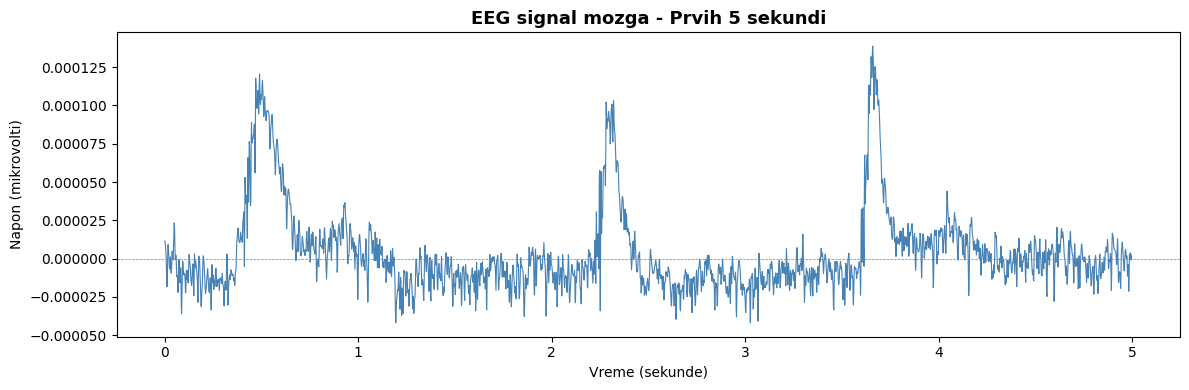

Svaki skok i pad na grafiku predstavlja aktivnost hiljada neurona!


In [3]:
# =====================================================================
# KORAK 1 & 2: INSTALACIJA, UCITAVANJE I CRTANJE EEG-a
# =====================================================================

# Instalacija biblioteke MNE za obradu neuro-signala (pokreće se samo jednom)
!pip install mne --quiet

import matplotlib.pyplot as plt
import mne
import numpy as np

print("Uvoz biblioteka završen. Učitavam stvarni EEG snimak...")

# Učitavanje integrisanog EEG snimka iz MNE baze
putanja = mne.datasets.sample.data_path()
fajl = putanja / "MEG" / "sample" / "sample_audvis_raw.fif"
snimak = mne.io.read_raw_fif(fajl, preload=True, verbose=False)

# Izdvajamo isključivo EEG kanale radi jednostavnosti
snimak.pick_types(eeg=True, verbose=False)

print("\n=== PODACI O SNIMKU MOZGA ===")
print(f"Broj merenih kanala (elektroda): {len(snimak.ch_names)}")
print(f"Trajanje celog snimka: {snimak.times[-1]:.0f} sekundi")
print(f"Frekvencija uzorkovanja: {snimak.info['sfreq']} merenja u sekundi")

# Izvlačenje sirovih podataka za vizuelizaciju
podaci = snimak.get_data()  # Matrica svih vrednosti
vreme = snimak.times  # Vremenska osa

# Crta se prvi kanal (indeks 0) za prvih 5 sekundi
fig, ax = plt.subplots(figsize=(12, 4))
pet_sekundi_uzorci = int(5 * snimak.info["sfreq"])

ax.plot(
    vreme[:pet_sekundi_uzorci],
    podaci[0, :pet_sekundi_uzorci],
    color="steelblue",
    linewidth=0.8,
)
ax.set_title("EEG signal mozga - Prvih 5 sekundi", fontsize=13, fontweight="bold")
ax.set_xlabel("Vreme (sekunde)")
ax.set_ylabel("Napon (mikrovolti)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()
print("Svaki skok i pad na grafiku predstavlja aktivnost hiljada neurona!")